In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

In [228]:
df = pd.read_csv('CC GENERAL.csv')

# Data Exploration and Preprocessing

In [229]:
df.shape

(8950, 18)

In [230]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [231]:
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

Features Description from Kaggle

<span style="color:green">CUST_ID</span> : Identification of Credit Card holder (Categorical) 

<span style="color:green">BALANCE</span> : Balance amount left in their account to make purchases 

<span style="color:green">BALANCE_FREQUENCY</span> : How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated) 

<span style="color:green">PURCHASES</span> : Amount of purchases made from account 

<span style="color:green">ONEOFF_PURCHASES</span> : Maximum purchase amount done in one-go 

<span style="color:green">INSTALLMENTS_PURCHASES</span> : Amount of purchase done in installment 

<span style="color:green">CASH_ADVANCE</span> : Cash in advance given by the user 

<span style="color:green">PURCHASES_FREQUENCY</span> : How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased) 

<span style="color:green">ONEOFFPURCHASESFREQUENCY</span> : How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased) 

<span style="color:green">PURCHASESINSTALLMENTSFREQUENCY</span> : How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done) 

<span style="color:green">CASHADVANCEFREQUENCY</span> : How frequently the cash in advance being paid 

<span style="color:green">CASHADVANCETRX</span> : Number of Transactions made with "Cash in Advanced" 

<span style="color:green">PURCHASES_TRX</span> : Numbe of purchase transactions made 

<span style="color:green">CREDIT_LIMIT</span> : Limit of Credit Card for user 

<span style="color:green">PAYMENTS</span> : Amount of Payment done by user 

<span style="color:green">MINIMUM_PAYMENTS</span> : Minimum amount of payments made by user 

<span style="color:green">PRCFULLPAYMENT</span> : Percent of full payment paid by user 

<span style="color:green">TENURE :</span> Tenure of credit card service for user

In [232]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [233]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

Dropping The customer id column as it has no effect on our data and might mislead the model

In [234]:
df.drop(columns='CUST_ID',inplace=True)

# Handling Missing Values

In [235]:
df.isnull().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Exploration of nulls is MINIMUM_PAYMENTS


In [236]:
df_mp_null = df[df['MINIMUM_PAYMENTS'].isna()].copy()
df_mp_null.info()

<class 'pandas.core.frame.DataFrame'>
Index: 313 entries, 3 to 8946
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           313 non-null    float64
 1   BALANCE_FREQUENCY                 313 non-null    float64
 2   PURCHASES                         313 non-null    float64
 3   ONEOFF_PURCHASES                  313 non-null    float64
 4   INSTALLMENTS_PURCHASES            313 non-null    float64
 5   CASH_ADVANCE                      313 non-null    float64
 6   PURCHASES_FREQUENCY               313 non-null    float64
 7   ONEOFF_PURCHASES_FREQUENCY        313 non-null    float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  313 non-null    float64
 9   CASH_ADVANCE_FREQUENCY            313 non-null    float64
 10  CASH_ADVANCE_TRX                  313 non-null    int64  
 11  PURCHASES_TRX                     313 non-null    int64  
 12  CREDIT_LIMIT

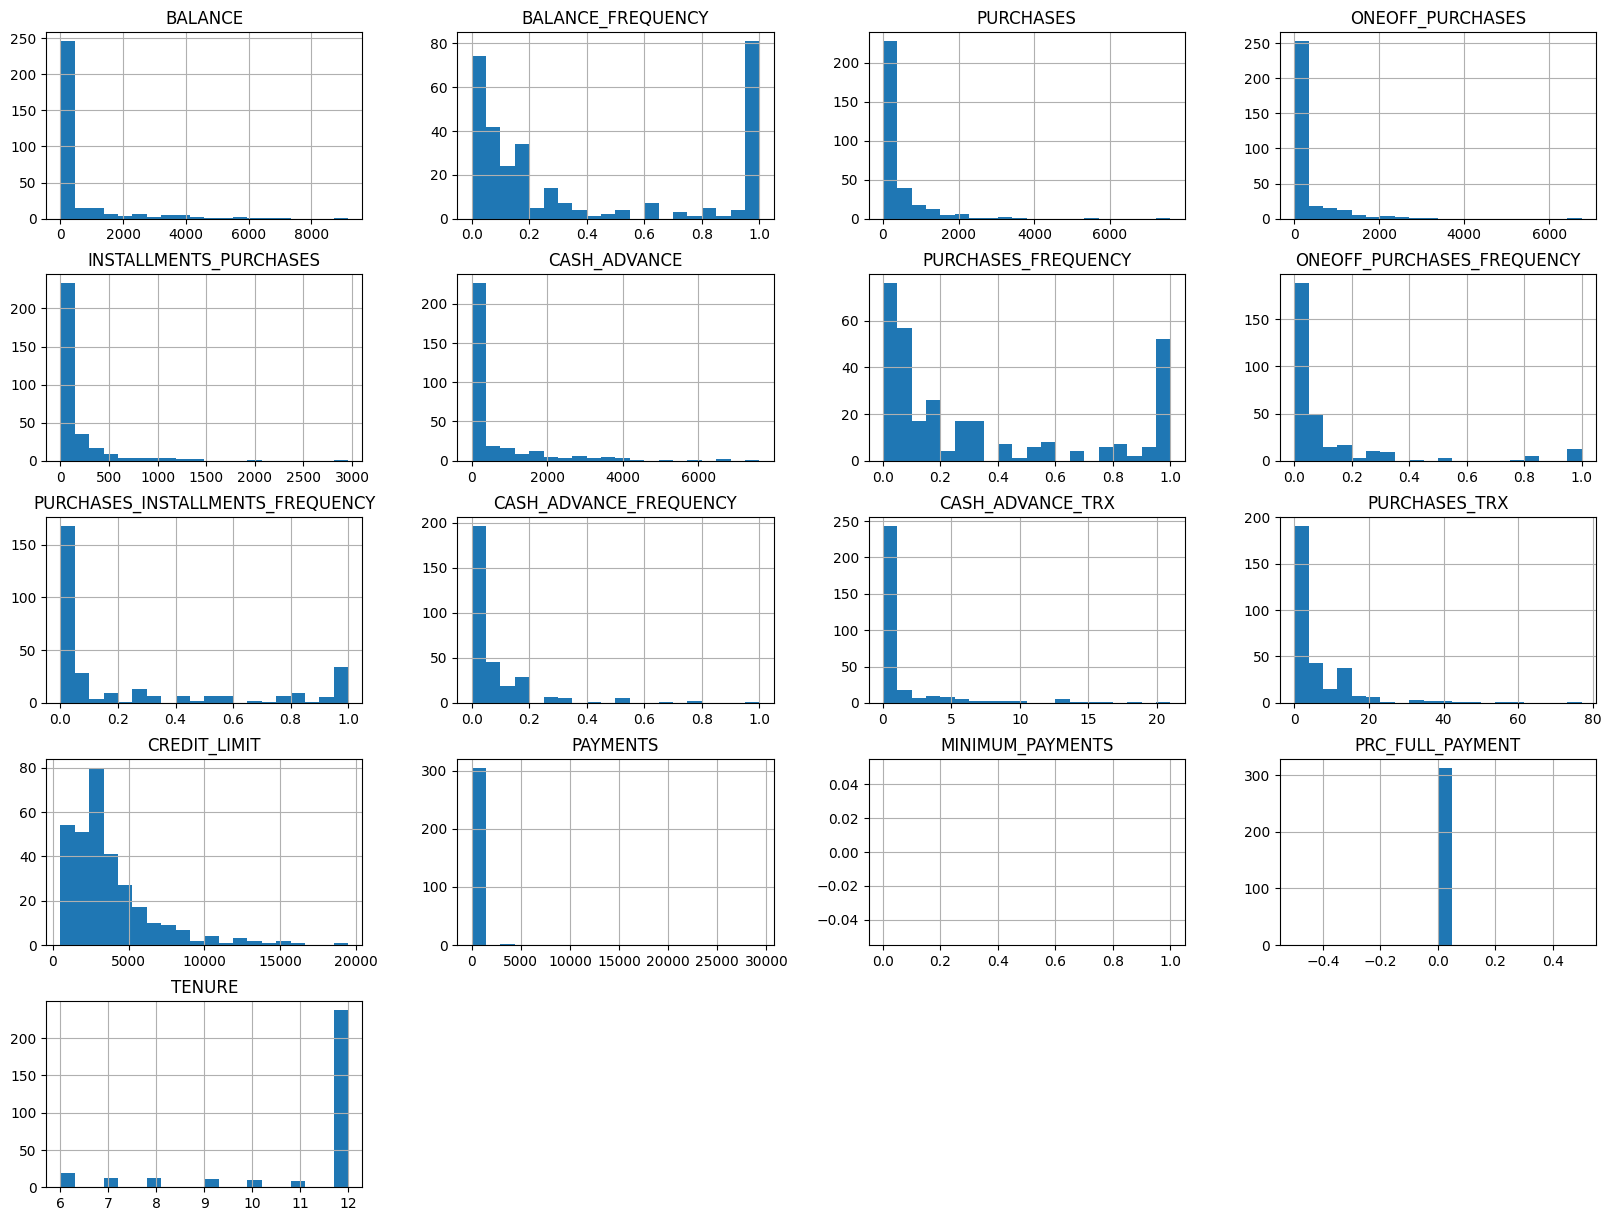

In [237]:
df_mp_null.hist(figsize = (20,15),bins=20)
plt.show()

The previous plots are to study the behaviour of customers having null minimum payments and find the reason 
we notice that these users typically have zero PAYMENTS , PRC_FULL_PAYMENT , BALANCE
so we go further exploring these

In [238]:
df_mp_null['PRC_FULL_PAYMENT'].value_counts()

PRC_FULL_PAYMENT
0.0    313
Name: count, dtype: int64

This could mean two things either the user owes nothing and paid nothing or the user owes money and paid nothing

Let's check the balance to confirm if these users typically owe money or not 

In [239]:
df_mp_null['BALANCE'].value_counts()

BALANCE
0.000000       74
1666.670542     1
207.632783      1
2.115080        1
37.324758       1
               ..
1.019189        1
3.574463        1
103.393689      1
1.600479        1
19.183215       1
Name: count, Length: 240, dtype: int64

In [240]:
zero_balance = df_mp_null[df_mp_null['BALANCE'] == 0] 
non_zero_balance = df_mp_null[df_mp_null['BALANCE'] != 0]

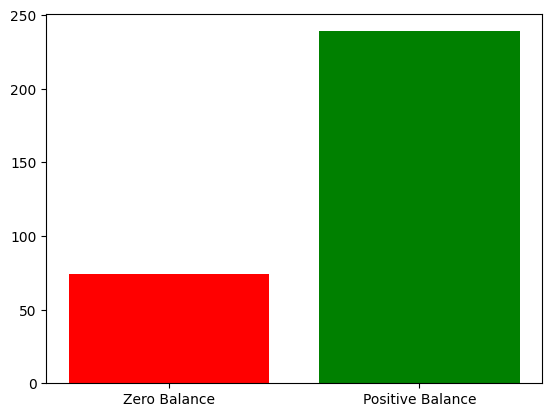

In [241]:
cat = ['Zero Balance','Positive Balance']
counts = [len(zero_balance),len(non_zero_balance)]
plt.bar(cat,counts,color=['red','green'])
plt.show()

we found that a percentage of users does not owe the bank any money so it is safe to assume that is the reason they have no minimum payment because they never owed the bank
so it is safe to impute these with zeroes

In [242]:
mask = (df['MINIMUM_PAYMENTS'].isna()) & (df['BALANCE'] == 0)
df.loc[mask,'MINIMUM_PAYMENTS'] = 0

I have decided to impute the remaining nulls using KNN Imputer as it will impute this feature using users with simalar behaviour at chosen features

In [244]:
scaler = StandardScaler()
imputation_cols = ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']

df_scaled = pd.DataFrame(scaler.fit_transform(df[imputation_cols]), columns=imputation_cols) ## we scale before knn

imputer = KNNImputer(n_neighbors=5, weights='distance') 

df_imputed_array = imputer.fit_transform(df_scaled)  ## we impute the missing vals using knn
df_imputed = pd.DataFrame(df_imputed_array, columns=imputation_cols)  

df_final_array = scaler.inverse_transform(df_imputed)
df_final = pd.DataFrame(df_final_array, columns=imputation_cols)                ## we do the unscaling to fill our original df
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df_final['MINIMUM_PAYMENTS'])

In [245]:
df.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        1
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [246]:
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

In [247]:
df.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

we have safely imputed the missing values from all features 

# Check for duplicates

In [248]:
df[df.duplicated()]

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE


In [249]:
df.to_csv('CC Imputed.csv',index=False)

In [250]:
df = pd.read_csv('CC Imputed.csv',)

In [251]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,748.420504,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


# Explore The data distributions and Preprocessing

In [252]:
df.describe(include='all')

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.282473,1733.143852,861.130581,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.646702,2895.063757,2378.304192,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,165.042304,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,299.252091,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,804.414788,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Box plots

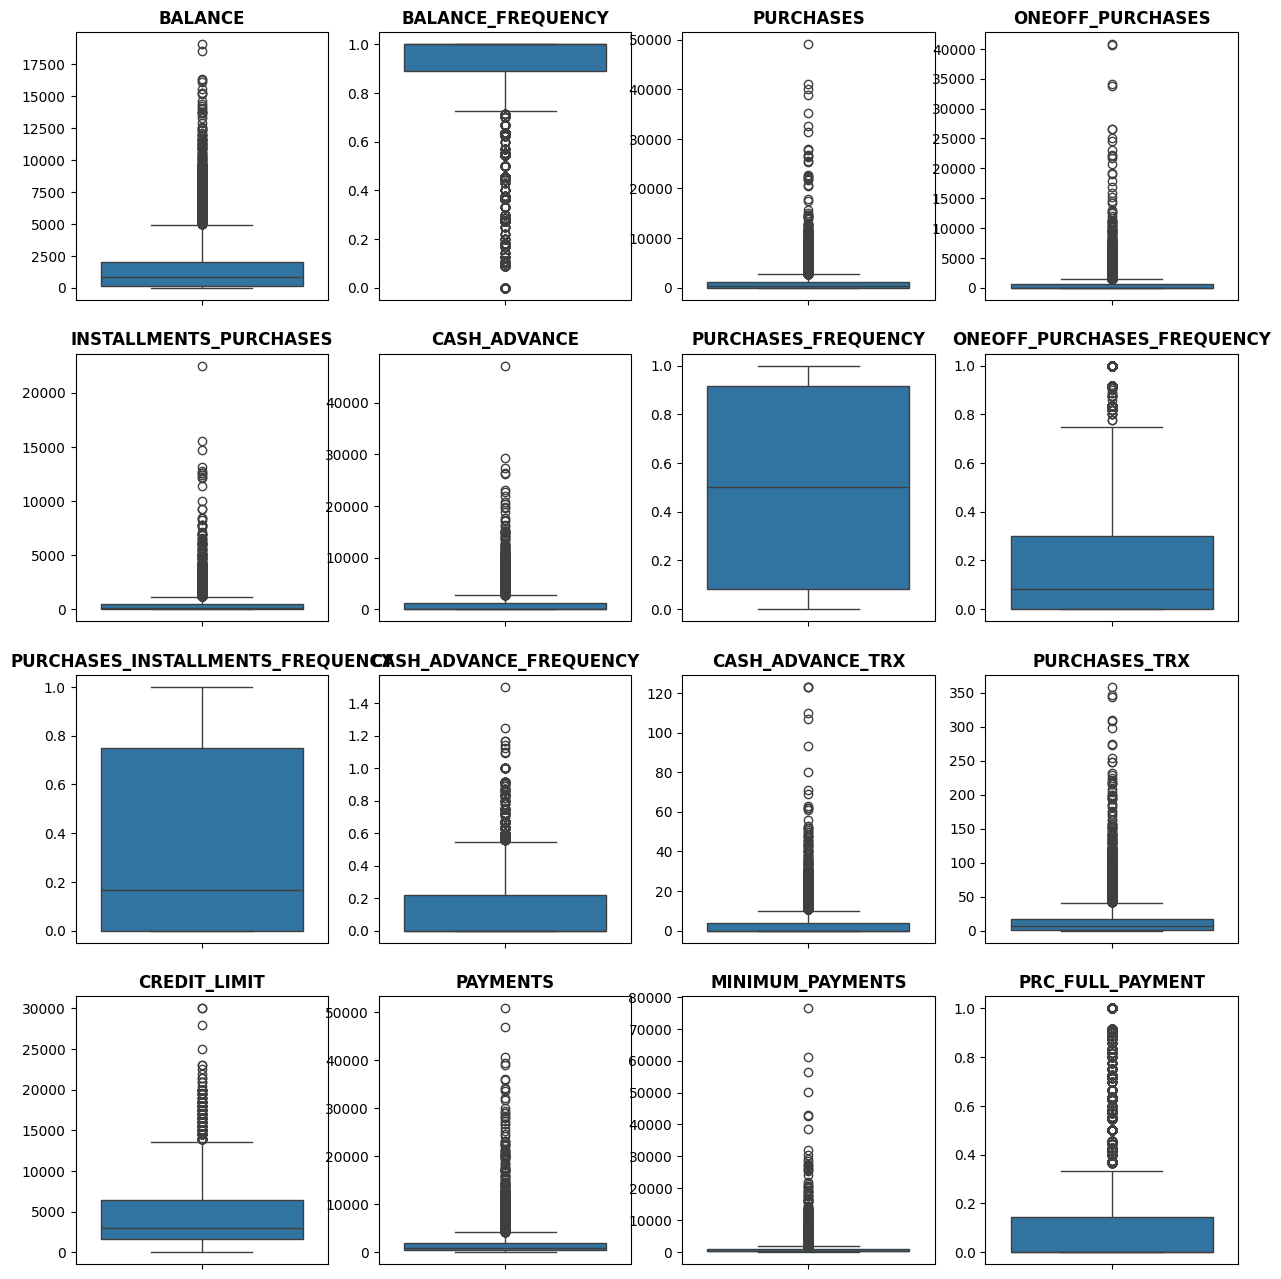

In [253]:
df_box = df[['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT']]
fig, axes = plt.subplots(4, 4, figsize=(15, 4* 4))
axes = axes.flatten()

for i, col in enumerate(df_box.columns.tolist()):
    sns.boxplot(data=df_box,ax=axes[i],y=col)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('')
plt.show()

we get the same inference that the data is right skewed
the high number of outliers is not noise but suggests that the data was sampled with higher middle-class people having certain ranges
in credit and certain usage than upper class 

This suggests that we need to do some transformations on data before feeding it to a model to move the outliers closer and fix the heavy right-skewness

Also CASH_ADVANCE_FREQUENCY has values greater than 1 which we need to inspect

In [254]:
df[df['CASH_ADVANCE_FREQUENCY'] >1]

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
681,5656.069801,1.000000,362.36,362.36,0.0,7240.433194,0.250000,0.250000,0.0,1.250000,12,2,8000.0,683.421497,2036.877611,0.0,8
1626,2876.009336,1.000000,152.61,152.61,0.0,3719.650168,0.333333,0.333333,0.0,1.166667,24,2,4000.0,248.342971,584.926336,0.0,6
2555,5906.184924,1.000000,141.80,141.80,0.0,1651.286918,0.125000,0.125000,0.0,1.125000,12,2,10000.0,933.969974,919.289675,0.0,8
2608,7801.511533,1.000000,231.40,231.40,0.0,4109.465221,0.100000,0.100000,0.0,1.100000,20,3,13500.0,1593.617739,1522.496755,0.0,10
3038,3846.742530,1.000000,0.00,0.00,0.0,1932.460679,0.000000,0.000000,0.0,1.500000,18,0,5600.0,496.245836,538.346874,0.0,6
3253,5709.486507,0.833333,0.00,0.00,0.0,2794.326341,0.000000,0.000000,0.0,1.166667,10,0,6000.0,550.513331,1299.463370,0.0,6
8055,1917.895730,1.000000,285.07,285.07,0.0,6084.858872,0.363636,0.363636,0.0,1.090909,28,6,3000.0,5692.682993,556.449635,0.0,11
8365,3857.562230,1.000000,0.00,0.00,0.0,2127.213754,0.000000,0.000000,0.0,1.142857,26,0,5000.0,617.508991,538.396872,0.0,7


this can be data entry error for these highly active in paying using cash_advance so we can cap these values at 1

In [255]:
df.loc[df['CASH_ADVANCE_FREQUENCY'] >1,'CASH_ADVANCE_FREQUENCY'] = 1

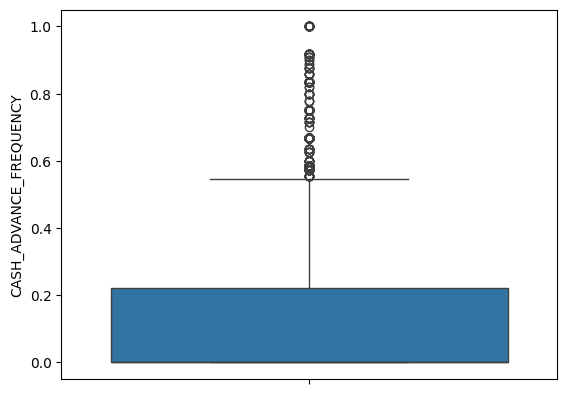

In [256]:
sns.boxplot(data=df,y='CASH_ADVANCE_FREQUENCY')
plt.show()

we have succesfully fixed these corrupted values

Now let's check for highly correlated features

## Correlation Matrix

<Axes: >

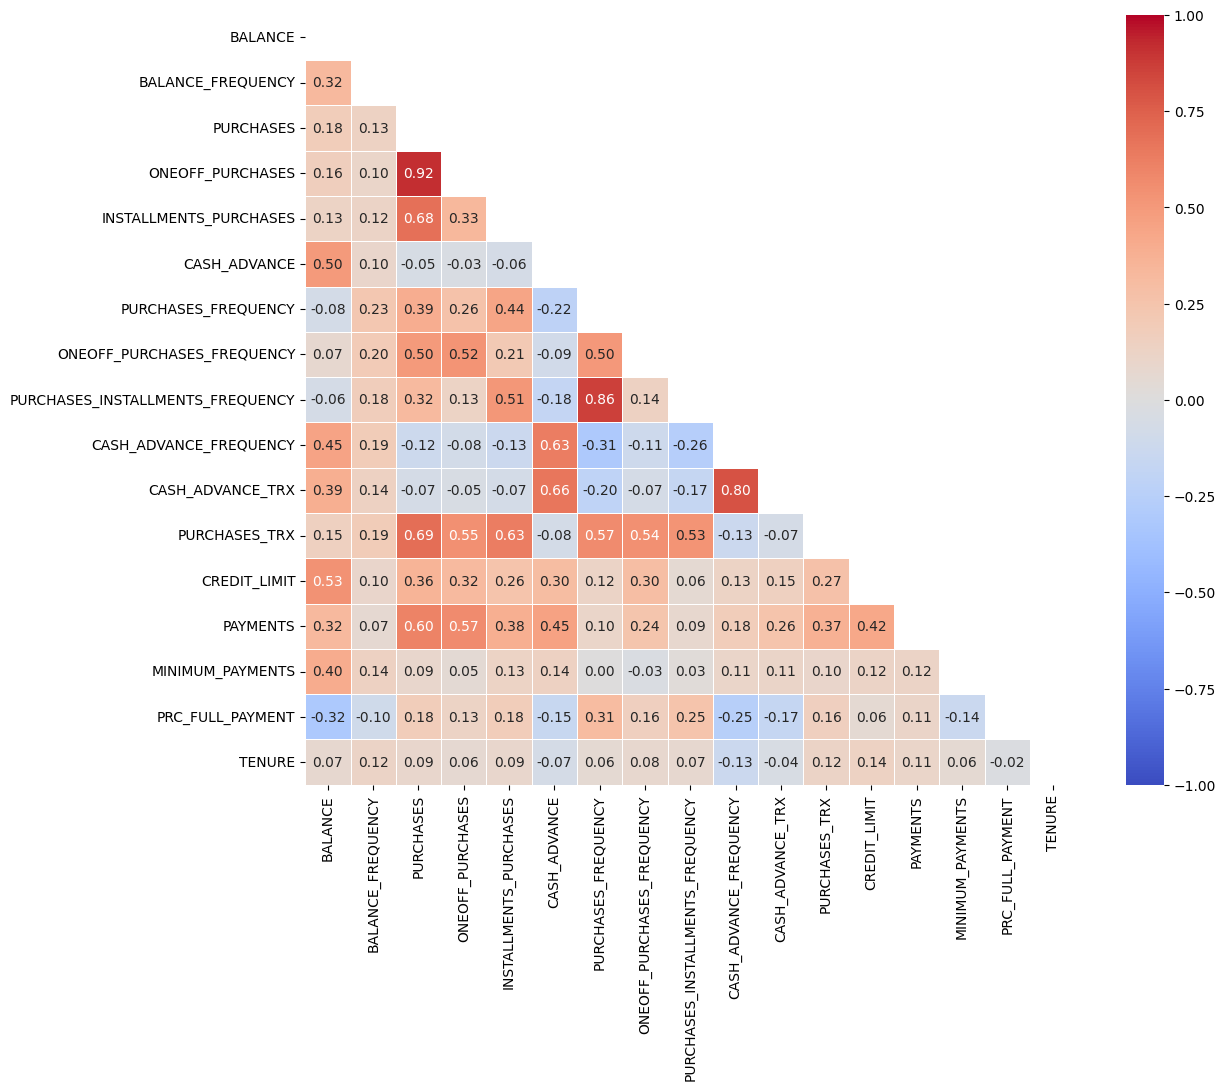

In [257]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(13, 10))

sns.heatmap(corr, 
            mask=mask,            
            cmap='coolwarm',      
            vmax=1,               
            vmin=-1,              
            center=0,             
            square=True,          
            linewidths=.5,        
            annot=True,           
            fmt='.2f')            

Some variables has strong and above moderate correlations with other variables

-for example ONEOFF_PURCHASES with PURCHASES (0.92) which suggests the linear relationship as people with high purchases usally have high oneoff purchases


-Also PURCHASES_FREQUENCY with PURCHASES_INSTALLMENTS_FREQUENCY

In [258]:
df['SUM_PURCHASES'] =  df['ONEOFF_PURCHASES'] + df['INSTALLMENTS_PURCHASES']

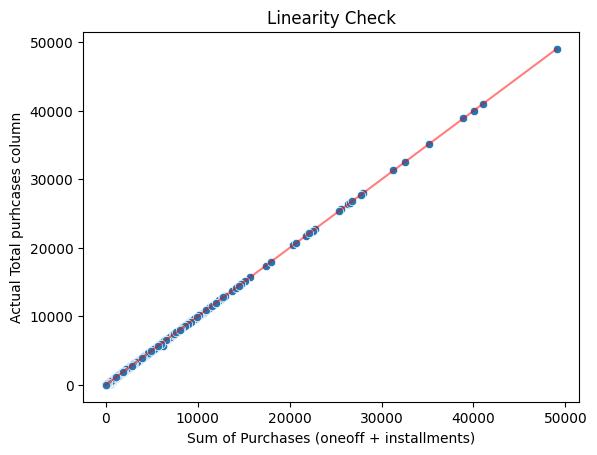

In [259]:
sns.scatterplot(data=df ,x='SUM_PURCHASES',y='PURCHASES')
plt.plot([0,df['PURCHASES'].max()],[0,df['PURCHASES'].max()],color='red',alpha = 0.5)
plt.xlabel('Sum of Purchases (oneoff + installments)')
plt.ylabel('Actual Total purhcases column')
plt.title('Linearity Check')
plt.show()

I suspected that there is multi-colinearity between total of 2 types of purchases and the purchases features and the scatter plot proves this

since PURCHASES is just sum of oneoff + installments purchases

so removing this feaeture would be a good practice since this columns add no info

In [260]:
df.drop(['PURCHASES','SUM_PURCHASES'],inplace=True,axis = 1)

Checking Features Distributions


## Features Histograms

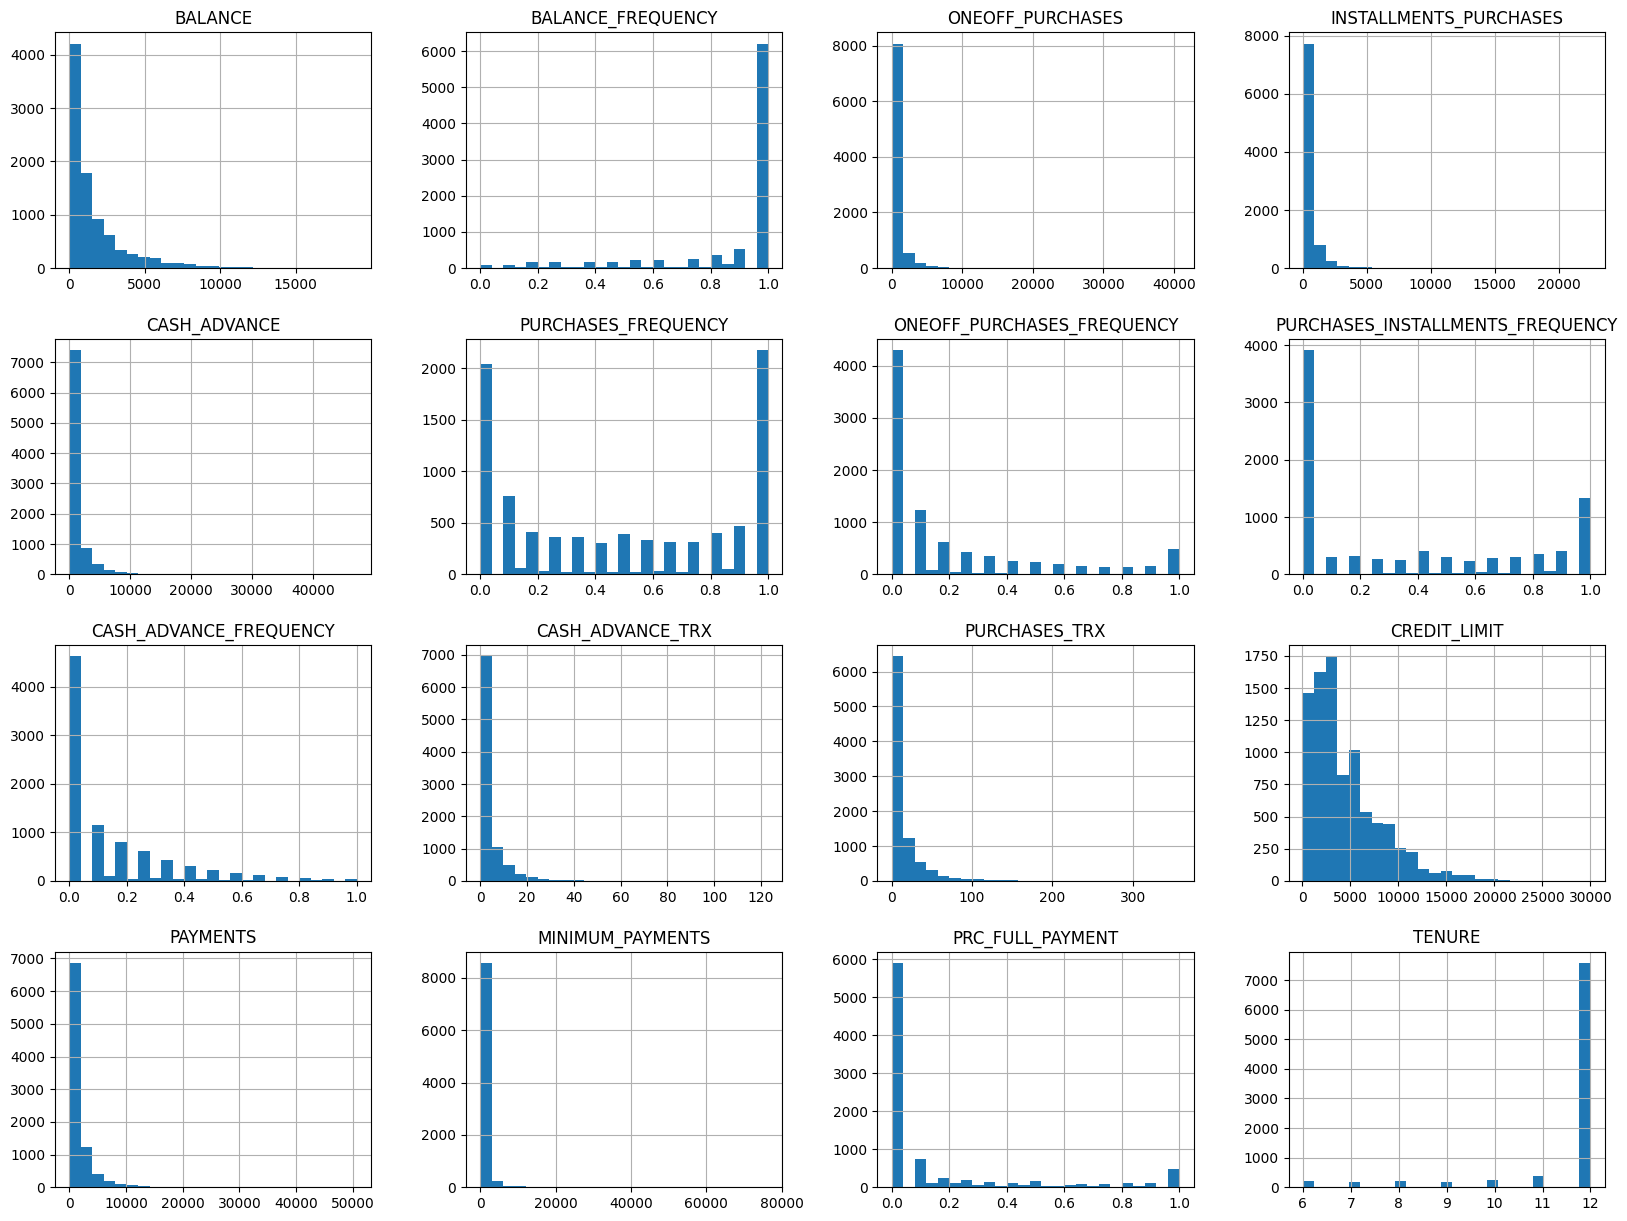

In [261]:
df.hist(figsize = (20,15),bins=25)
plt.show()

we notice the data is heavily right skewed in most of the features which is reasonable as this suggests people using credit card are more in middle lower class than these in higher class which is less


the BALANCE_FREQUENCY column is left skewed with most values at '1' suggesting that most of users use the credit card frequently

Let's Fix The skewness of The data using log transformation for right skewed features with high ranges 

(we wont do transformation on frequency features or percentages  since they are ranged from 0 to 1 and log transformation won't help us)

(same applies to categorical data (tenure))

In [262]:
df.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')

In [263]:
log_columns = ['BALANCE' ,'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE' , 
               'CASH_ADVANCE_TRX', 'PURCHASES_TRX','CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS' ]
df[log_columns] = df[log_columns].map(lambda x : np.log1p(x))

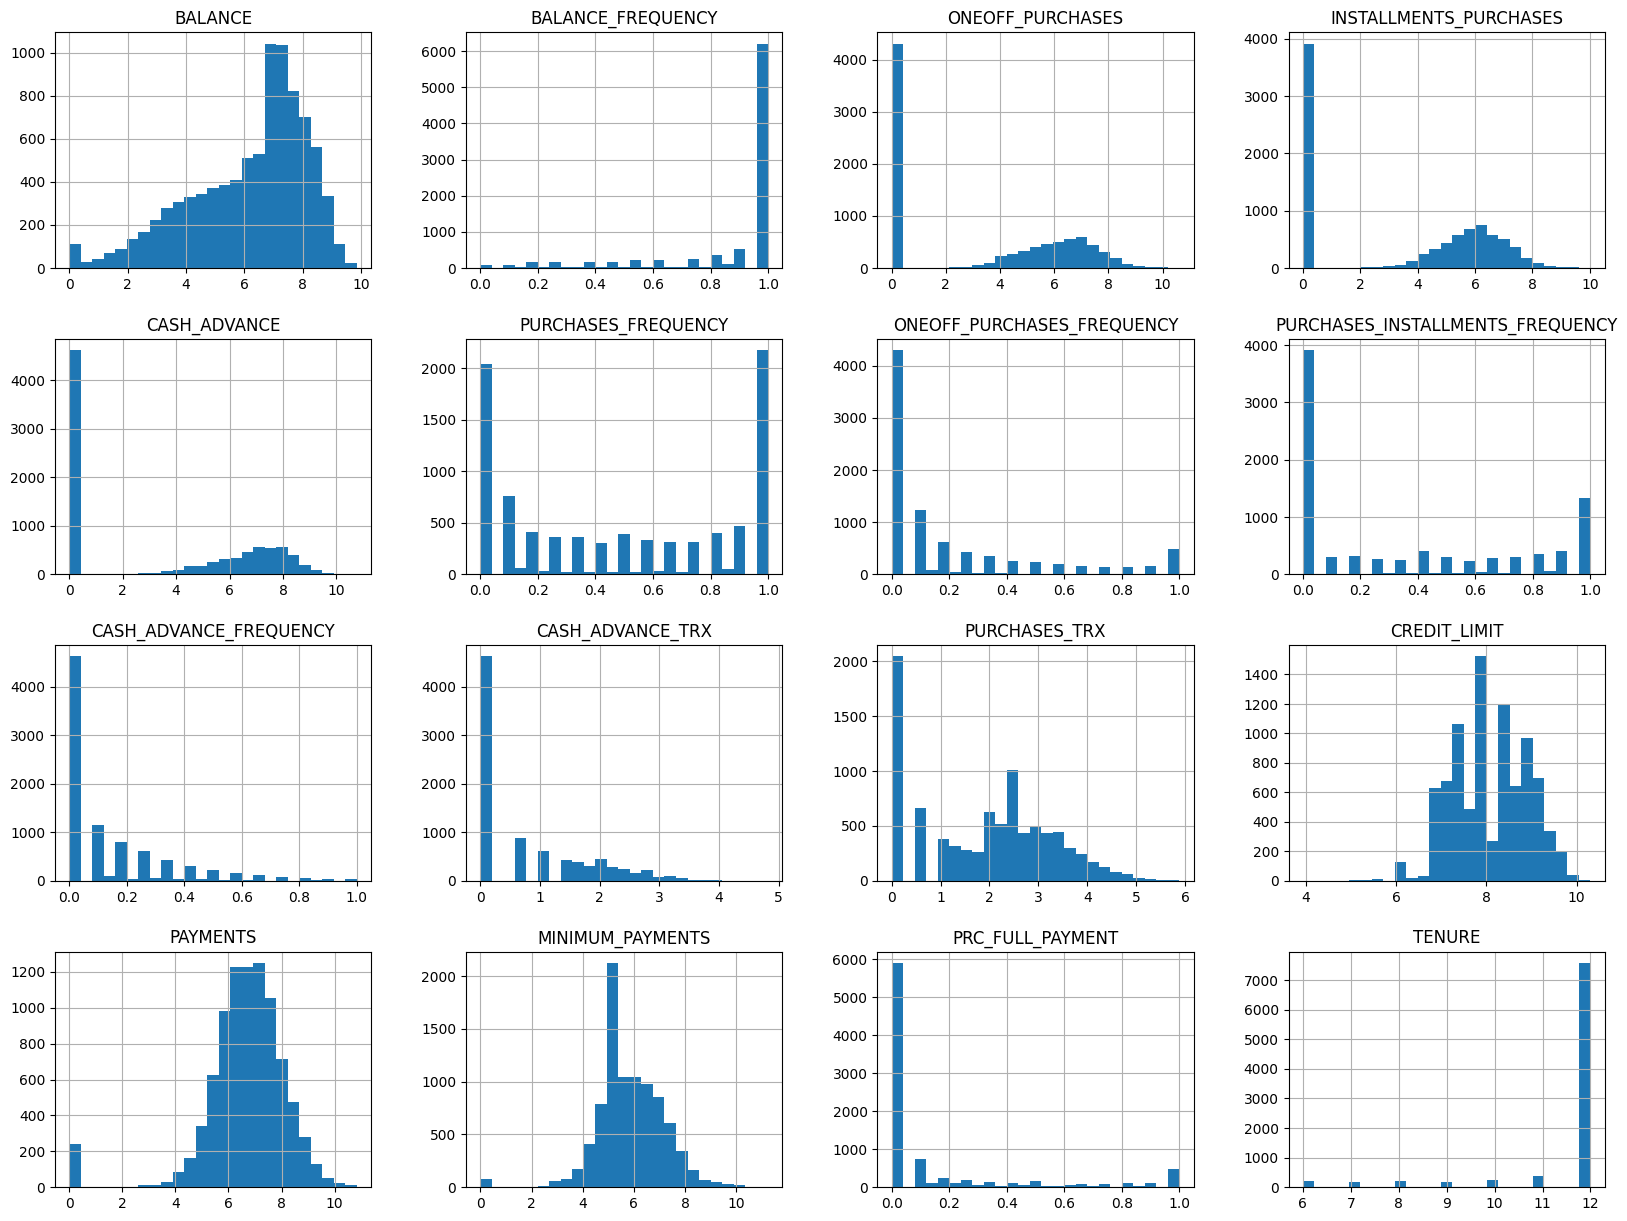

In [264]:
df.hist(figsize = (20,15),bins=25)
plt.show()

In [265]:
df.to_csv('CC Preprocessed.csv',index=False)